# 🎬 Análise da Relação entre Orçamento e Desempenho de Bilheteria

## ❓ Problema de Pesquisa
**Existe evidência de uma relação positiva entre o orçamento de um filme e seu desempenho de bilheteria?**

Este estudo busca investigar a relação entre o investimento realizado na produção de um filme e sua arrecadação global.

---

## 💡 Hipótese

Existe uma relação positiva e estatisticamente significativa entre o orçamento e a bilheteria. (Filmes com maiores orçamentos tendem a gerar maiores receitas globais).

---

## 📊 Seleção das Variáveis

Para esta análise, foram selecionadas as seguintes colunas:

- **Budget (in $)**  
  Representa o orçamento do filme, ou seja, o valor total investido em sua produção (em dólares).

- **World Wide Sales (in $)**  
  Representa a receita total obtida pelo filme em bilheteria mundial.

---

## 📥 Carregamento dos Dados

In [15]:
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np

handle = "sanjeetsinghnaik/top-1000-highest-grossing-movies"
file_path = "Highest Holywood Grossing Movies.csv"

df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, handle, file_path)

df = df[['Title', 'Budget (in $)', 'World Wide Sales (in $)']]
display(df.head())

Using Colab cache for faster access to the 'top-1000-highest-grossing-movies' dataset.


,Title,Budget (in $),World Wide Sales (in $)
0,Avatar,237000000,2923706026
1,Avengers: Endgame,356000000,2799439100
2,Avatar: The Way of Water,December 14 2022 (EMEA APAC),2320250281
3,Titanic,200000000,2264743305
4,Star Wars: Episode VII - The Force Awakens,245000000,2071310218


## 🧹 Tratamento dos Dados

Nenhuma base de dados do mundo real é perfeita. Nesta etapa, realizamos a limpeza e conversão de tipos para garantir a integridade da análise estatística.

Passos realizados:
1. Identificação e Conversão de Tipos: Notamos que a coluna Budget (in $) foi importada como string (texto), inclusive contendo datas misturadas em alguns registros (ex: "December 14 2022"). Utilizamos a função pd.to_numeric com o parâmetro errors='coerce' para forçar a conversão para numérico (float), transformando qualquer texto inválido em valores nulos (NaN).
2. Tratamento de Valores Ausentes: Removemos as linhas que ficaram com valores ausentes (NaN) na coluna de orçamento, pois sem esse dado é impossível calcular as métricas para a nossa pergunta de pesquisa.

In [16]:
# Converter para numérico
df['Budget (in $)'] = pd.to_numeric(df['Budget (in $)'], errors='coerce')

# Remover valores nulos
df = df.dropna(subset=['Budget (in $)'])

display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 785 entries, 0 to 998
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    785 non-null    object 
 1   Budget (in $)            785 non-null    float64
 2   World Wide Sales (in $)  785 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 24.5+ KB


None

## 📏 Estatística Descritiva: Centralização, Posição, Dispersão e Forma

Para entendermos o comportamento do Orçamento e da Bilheteria, calculamos as principais métricas estatísticas:
* Centralização: Média, Mediana e Moda.
* Posição: Quartil 1 (Q1) e Quartil 3 (Q3).
* Dispersão: Amplitude (Range), Variância e Desvio Padrão.
* Forma da Distribuição: Assimetria (Skewness) e Curtose (Kurtosis).

In [17]:
vars_interesse = ['Budget (in $)', 'World Wide Sales (in $)']

desc_stats = pd.DataFrame({
    'Média': df[vars_interesse].mean(),
    'Mediana': df[vars_interesse].median(),
    'Moda': df[vars_interesse].mode().iloc[0],
    'Q1 (25%)': df[vars_interesse].quantile(0.25),
    'Q3 (75%)': df[vars_interesse].quantile(0.75),
    'Amplitude': df[vars_interesse].max() - df[vars_interesse].min(),
    'Variância': df[vars_interesse].var(),
    'Desvio Padrão': df[vars_interesse].std(),
    'Assimetria (Skew)': df[vars_interesse].skew(),
    'Curtose (Kurtosis)': df[vars_interesse].kurtosis()
}).T

display(desc_stats)

,Budget (in $),World Wide Sales (in $)
Média,9.742392e+07,4.224737e+08
Mediana,8.500000e+07,3.221612e+08
Moda,1.500000e+08,1.820166e+08
Q1 (25%),5.000000e+07,2.312526e+08
Q3 (75%),1.400000e+08,4.917301e+08
Amplitude,3.559850e+08,2.743148e+09
Variância,3.683705e+15,8.793916e+16
Desvio Padrão,6.069353e+07,2.965454e+08
Assimetria (Skew),7.486876e-01,3.023085e+00
Curtose (Kurtosis),3.126590e-01,1.534279e+01


Interpretação: Observando a Assimetria, vemos valores bem maiores que zero, indicando uma distribuição fortemente assimétrica à direita (positiva). Isso significa que a maioria dos filmes tem orçamentos/receitas menores, enquanto poucos blockbusters puxam a média para cima. A Curtose altíssima confirma que a distribuição é leptocúrtica (caudas longas com muitos outliers extremos). Consequentemente, a Mediana torna-se uma medida de centralização mais representativa que a Média.

## ⚖️ Padronização de Dados (Z-Score)Como Orçamento e Receita possuem grandezas elevadas e dispersões muito diferentes, aplicamos a padronização

utilizando o Z-Score. Essa técnica nos indica quantos desvios padrão um filme está acima ou abaixo da média, facilitando a identificação estatística de outliers extremos ($Z > 3$).

In [18]:
from scipy.stats import zscore

df['Z-Score Budget'] = zscore(df['Budget (in $)'])
df['Z-Score Revenue'] = zscore(df['World Wide Sales (in $)'])

# Exibindo os 5 filmes mais fora da curva (Outliers extremos) baseados no Orçamento
display(df[['Title', 'Budget (in $)', 'Z-Score Budget', 'World Wide Sales (in $)', 'Z-Score Revenue']].sort_values(by='Z-Score Budget', ascending=False).head())

,Title,Budget (in $),Z-Score Budget,World Wide Sales (in $),Z-Score Revenue
1,Avengers: Endgame,356000000.0,4.263073,2799439100,8.020630
18,Star Wars: Episode VIII - The Last Jedi,317000000.0,3.620090,1334407706,3.077153
59,Pirates of the Caribbean: At World's End,300000000.0,3.339816,961691209,1.819490
196,Mission: Impossible - Dead Reckoning Part One,291000000.0,3.191436,567535383,0.489484
36,Star Wars: Episode IX - The Rise of Skywalker,275000000.0,2.927648,1077022372,2.208653


## 📈 Criação de Métricas Derivadas

Foram criadas métricas adicionais para enriquecer a análise financeira:

Profit (Lucro): Receita - Orçamento

ROI (Return on Investment): Profit / Budget

Profit Margin: Profit / Receita

Risk Return: ROI / Budget

Também segmentamos os filmes por faixa de orçamento usando quartis.

In [19]:
df['Profit'] = df['World Wide Sales (in $)'] - df['Budget (in $)']
df['ROI'] = df['Profit'] / df['Budget (in $)']
df['Profit Margin'] = df['Profit'] / df['World Wide Sales (in $)']
df['Risk Return'] = df['ROI'] / df['Budget (in $)']

# Segmentação por faixa de orçamento (Quartis)
df['Budget Category'] = pd.qcut(
    df['Budget (in $)'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Blockbuster']
)

display(df.head())

,Title,Budget (in $),World Wide Sales (in $),Z-Score Budget,Z-Score Revenue,Profit,ROI,Profit Margin,Risk Return,Budget Category
0,Avatar,237000000.0,2923706026,2.301152,8.439946,2.686706e+09,11.336312,0.918938,4.783254e-08,Blockbuster
1,Avengers: Endgame,356000000.0,2799439100,4.263073,8.020630,2.443439e+09,6.863593,0.872832,1.927976e-08,Blockbuster
3,Titanic,200000000.0,2264743305,1.691144,6.216398,2.064743e+09,10.323717,0.911690,5.161858e-08,Blockbuster
4,Star Wars: Episode VII - The Force Awakens,245000000.0,2071310218,2.433046,5.563694,1.826310e+09,7.454327,0.881717,3.042583e-08,Blockbuster
7,Jurassic World,150000000.0,1671537444,0.866807,4.214735,1.521537e+09,10.143583,0.910262,6.762389e-08,Blockbuster


## 📊 Visualização de Distribuição (Histograma + KDE)

O gráfico abaixo sobrepõe um Histograma com a Curva de Densidade Estimada (KDE) para ilustrar a assimetria da receita mundial. Destacamos também a Média e a Mediana.

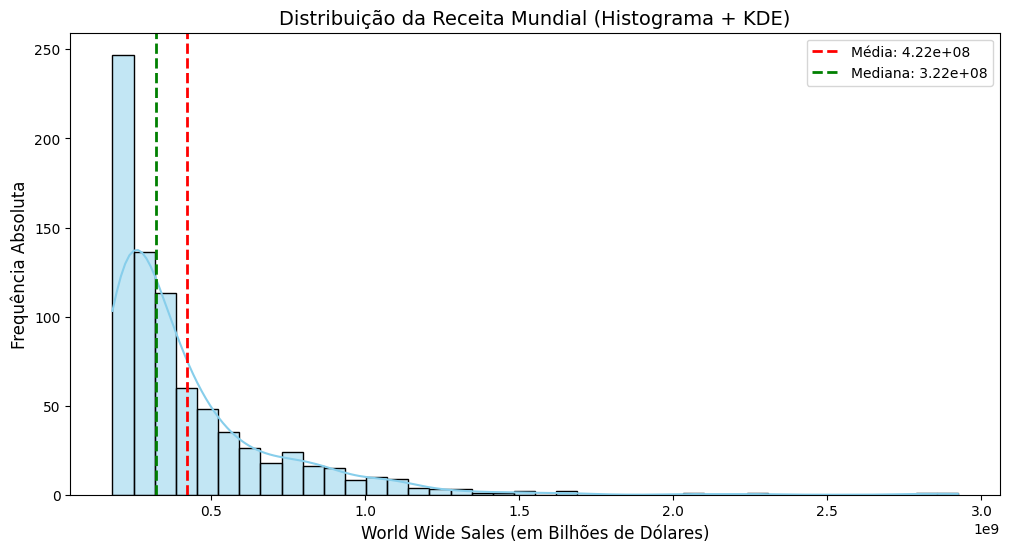

In [20]:
plt.figure(figsize=(12, 6))
sns.histplot(df['World Wide Sales (in $)'], bins=40, kde=True, color='skyblue', edgecolor='black')

# Adicionando linhas de Média e Mediana
plt.axvline(df['World Wide Sales (in $)'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Média: {df['World Wide Sales (in $)'].mean():.2e}")
plt.axvline(df['World Wide Sales (in $)'].median(), color='green', linestyle='dashed', linewidth=2, label=f"Mediana: {df['World Wide Sales (in $)'].median():.2e}")

plt.title('Distribuição da Receita Mundial (Histograma + KDE)', fontsize=14)
plt.xlabel('World Wide Sales (em Bilhões de Dólares)', fontsize=12)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.legend()
plt.show()

## 🔍 Análise de Correlação

### Correlação linear

A matriz de correlação Linear de Pearson nos ajuda a entender a força e a direção da relação entre o orçamento e nossas métricas financeiras.

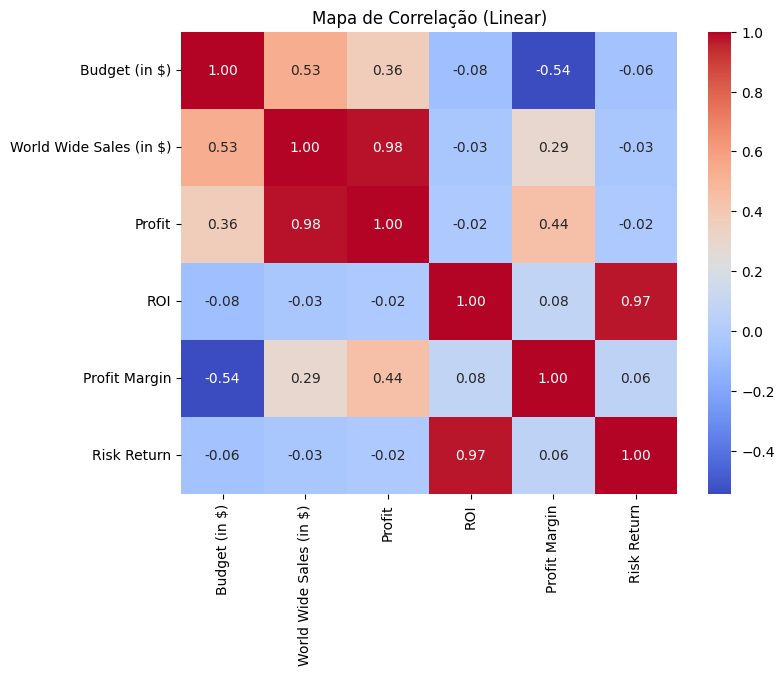

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['Budget (in $)', 'World Wide Sales (in $)', 'Profit', 'ROI', 'Profit Margin', 'Risk Return']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Mapa de Correlação (Linear)')
plt.show()

### Correlação logarítmica

Devido à extrema assimetria positiva, aplicamos o logaritmo para normalizar as distribuições e visualizar a correlação sem a distorção dos grandes outliers.

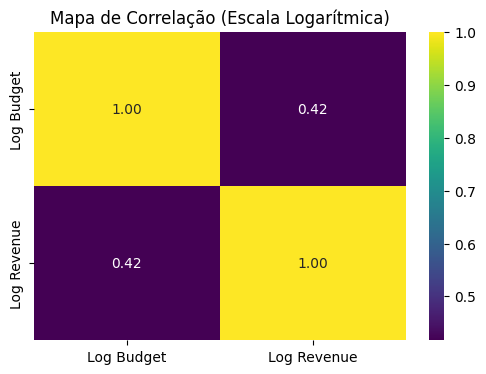

In [22]:
df['Log Budget'] = np.log(df['Budget (in $)'])
df['Log Revenue'] = np.log(df['World Wide Sales (in $)'])

plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['Log Budget', 'Log Revenue']].corr(),
    annot=True,
    cmap='viridis',
    fmt=".2f"
)
plt.title('Mapa de Correlação (Escala Logarítmica)')
plt.show()

## 📊 Visualização

A visualização permite observar padrões e possíveis relações entre as variáveis:

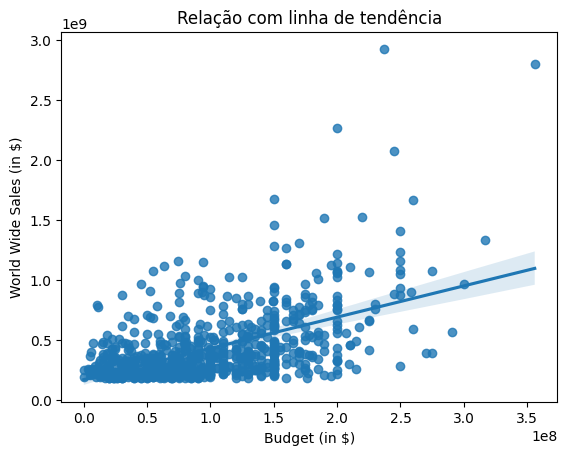

In [23]:
sns.regplot(x='Budget (in $)', y='World Wide Sales (in $)', data=df)
plt.title('Relação com linha de tendência')
plt.show()

## 📌 Análise por Faixa de Orçamento

Para entender como o retorno varia entre diferentes níveis de investimento:

In [24]:
df.groupby('Budget Category')['ROI'].median()

/tmp/ipykernel_17021/1167986843.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Budget Category')['ROI'].median()


,ROI
Budget Category,
Low,8.255996
Medium,2.896446
High,2.179538
Blockbuster,2.059399


# ✅ Conclusão

A análise realizada permite identificar padrões importantes na relação entre o orçamento de um filme e seu desempenho financeiro.

Inicialmente, observa-se uma correlação positiva moderada (0.53) entre o orçamento (Budget) e a receita global (World Wide Sales). Esse resultado indica que, em média, filmes com maior investimento tendem a gerar maior arrecadação. No entanto, essa relação não é forte o suficiente para afirmar que o aumento do orçamento garante, por si só, um maior desempenho de bilheteria.

Quando analisamos o lucro (Profit), a correlação com o orçamento é ainda mais baixa (0.36), sugerindo que, embora filmes mais caros arrecadem mais, isso não necessariamente se traduz em maior lucro proporcional.

Por outro lado, a correlação entre receita e lucro é extremamente alta (0.98), o que é esperado, já que o lucro depende diretamente da receita obtida. Esse resultado reforça a consistência dos dados.

Um dos pontos mais relevantes da análise é a relação entre orçamento e eficiência do investimento. A correlação entre orçamento e ROI é ligeiramente negativa (-0.08), enquanto a correlação com a margem de lucro (Profit Margin) é moderadamente negativa (-0.54). Isso indica que filmes com maior orçamento tendem a ser menos eficientes em termos de retorno proporcional, ou seja, apesar de arrecadarem mais em valores absolutos, geram menor retorno relativo sobre o investimento.

A análise com transformação logarítmica confirma esse comportamento, apresentando uma correlação moderada (0.42) entre orçamento e receita, sugerindo uma relação positiva, porém não linear. Isso indica que o crescimento da receita não acompanha proporcionalmente o aumento do investimento.

Além disso, a segmentação por faixa de orçamento revela um padrão bastante expressivo: filmes de baixo orçamento apresentam um ROI médio extremamente elevado (96.04), enquanto filmes de médio, alto orçamento e blockbusters apresentam valores significativamente menores (entre aproximadamente 2.5 e 3.8). Esse resultado evidencia que filmes mais baratos possuem maior potencial de retorno proporcional, embora frequentemente com maior variabilidade e presença de outliers.

## 🎯 Síntese Final

Com base nos resultados, conclui-se que:

- Existe evidência de relação positiva entre orçamento e receita, mas de intensidade moderada  
- Filmes com maior orçamento tendem a gerar maior receita e lucro absoluto  
- No entanto, apresentam menor eficiência financeira (ROI e margem de lucro)  
- Filmes de baixo orçamento, embora mais arriscados, podem gerar retornos proporcionais muito superiores  

## 🧠 Interpretação Geral

Portanto, o investimento em grandes produções está associado a maior previsibilidade de receita, enquanto produções de baixo orçamento apresentam maior potencial de retorno relativo, porém com maior risco.
